## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import plotly.graph_objs as go
import warnings

from plotly.offline import plot
from plotly.subplots import make_subplots
from reeb_utils import collapse_traj


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## Load data into dataframe

In [12]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

test_df["StartEnd"] = test_df["StartAt"] + "_" + test_df["EndAt"]

# Calculate trajectory (no turns, just nodes)
test_df["trajs"] = test_df["paths"].apply(lambda x: "".join(collapse_traj(x.split())))

# need to set this to do the masking below; else error
test_df["accuracy"] = test_df["accuracy"].astype('bool')

# Calculate min turns; first set turns very high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_turns"] = test_df["turns_count"]
test_df.loc[~test_df["accuracy"], "fake_turns"] = 999

test_df["min_turns"] = test_df.groupby("StartEnd")["fake_turns"].transform("min")

# Calculate min path dist; first set v high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_dist"] = test_df["trajs"].apply(len)
test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

# test_df[["path_mean_acc_by_Q", "quartile", "StartAt", "EndAt"]]

## Plotting function

In [4]:
# Function to create traces for the bars and the dotted line for average accuracy
def create_trace(data, color_column, group_column, name):
    traces = []
    tickvals = []
    ticktext = []
    
    for group in data[group_column].unique():
        group_data = data[data[group_column] == group]
        # Bar trace
        bar_trace = go.Bar(
            x=group_data["StartEnd"],
            y=group_data["accuracy"],
            marker=dict(color=group_data[color_column]),
            opacity=0.7,
            # name=f"{name}: {group}",
            hovertemplate=(
                f"<br>" +
                "%{customdata}, %{y:.2f}<extra></extra>"
            ),
            customdata=group_data["StartEnd"],
            showlegend=False
        )
        traces.append(bar_trace)
        
        # Dotted line for average accuracy
        avg_accuracy = group_data["accuracy"].mean()
        line_trace = go.Scatter(
            x=group_data["StartEnd"],
            y=[avg_accuracy] * len(group_data),
            mode='lines',
            line=dict(dash='dot', color=group_data[color_column].iloc[0], width=2),
            name=f"Avg {name}: {group}, {avg_accuracy}",
            hovertemplate=(
                f"<b>{name}: {group}</b><br>" +
                "Avg Accuracy: %{y:.2f}<extra></extra>"
            ),
            showlegend=False
        )
        traces.append(line_trace)

        # Custom tick text for the x-axis, center the tick text
        mid_index = len(group_data) // 2
        tickvals.append(group_data["StartEnd"].iloc[mid_index])
        ticktext.append(group)
    
    return traces, tickvals, ticktext

## Do the plotting

   StartAt EndAt  accuracy StartEnd
0        A     I  0.545455      A_I
1        A     K  0.530303      A_K
2        A     L  0.728571      A_L
3        A     N  0.716418      A_N
4        A     O  0.696970      A_O
..     ...   ...       ...      ...
67       Y     L  0.500000      Y_L
68       Y     N  0.528571      Y_N
69       Y     O  0.583333      Y_O
70       Y     P  0.588235      Y_P
71       Y     W  0.656716      Y_W

[72 rows x 4 columns]


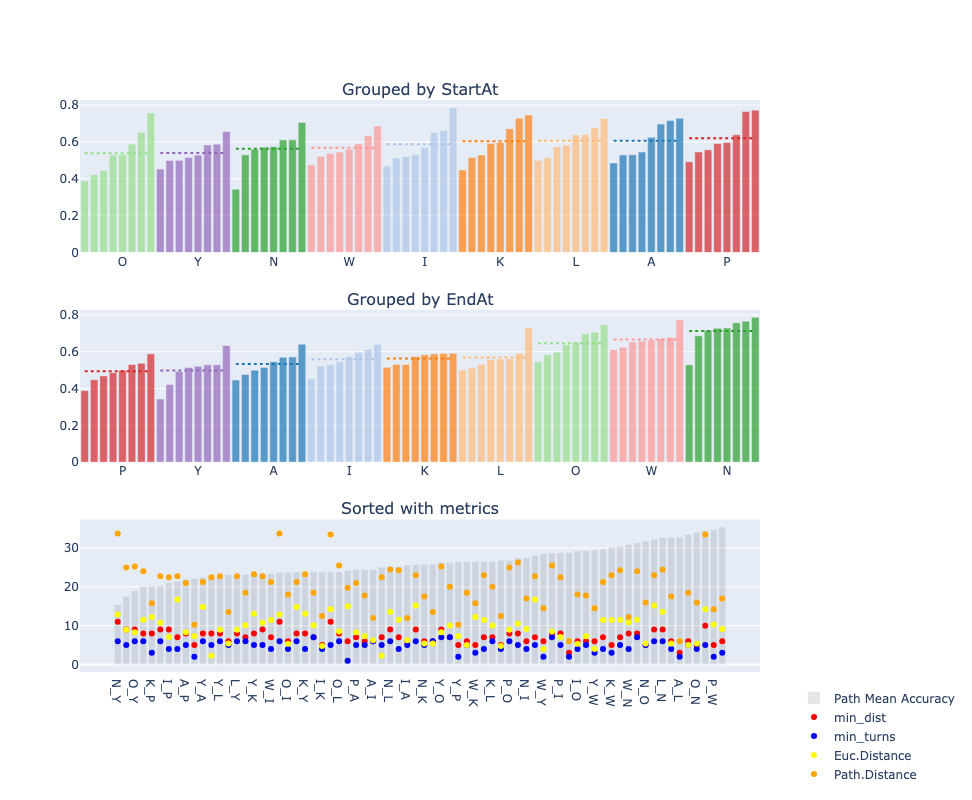

'figures/grouped_by_start_end.html'

In [47]:
# Assuming test_df is your initial DataFrame
new_df = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean().reset_index()
new_df["StartEnd"] = new_df["StartAt"] + "_" + new_df["EndAt"]

print(new_df)
color_dict = {k: f'rgb({v[0]*255},{v[1]*255},{v[2]*255})' for k, v in zip(new_df["StartAt"].unique(), plt.get_cmap('tab20').colors)}

# # Create the layout for subplots
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.1, subplot_titles=("Grouped by StartAt", "Grouped by EndAt", "Sorted with metrics"))

# Sorting by StartAt
avg_startat = new_df.groupby("StartAt")["accuracy"].mean().sort_values()
new_df["StartAt"] = pd.Categorical(new_df["StartAt"], categories=avg_startat.index, ordered=True)
new_df = new_df.sort_values(["StartAt", "accuracy"])
new_df["colors_start"] = new_df["StartAt"].apply(lambda x: color_dict[x])

# Add traces for StartAt groups
traces_start, tickvals_start, ticktext_start = create_trace(new_df, "colors_start", "StartAt", "StartAt")
for trace in traces_start:
    fig.add_trace(trace, row=1, col=1)
  
# Sorting by EndAt
avg_endat = new_df.groupby("EndAt")["accuracy"].mean().sort_values()
new_df["EndAt"] = pd.Categorical(new_df["EndAt"], categories=avg_endat.index, ordered=True)
new_df = new_df.sort_values(["EndAt", "accuracy"])
new_df["colors_end"] = new_df["EndAt"].apply(lambda x: color_dict[x])

# Add traces for EndAt groups
traces_end, tickvals_end, ticktext_end = create_trace(new_df, "colors_end", "EndAt", "EndAt")
for trace in traces_end:
    fig.add_trace(trace, row=2, col=1)

## Add third plot
# Assuming test_df is your initial DataFrame
metrics_to_plot = ["min_dist", "min_turns", "Euc.Distance", "Path.Distance"]
colors = ["red", "blue", "yellow", "orange"]

# Prepare data
path_accs = test_df[["StartEnd", "path_mean_acc"] + metrics_to_plot].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

# Bar plot for path mean accuracy
bar_trace = go.Bar(
    x=path_accs["StartEnd"],
    y=path_accs["path_mean_acc"]*45,
    marker=dict(color="rgba(0, 0, 0, 0.1)"),
    name="Path Mean Accuracy",
    xaxis="x3",
    yaxis="y11",
    hovertemplate="StartEnd: %{x}<br>Path Mean Accuracy: %{customdata:.2f}<extra></extra>",
    customdata=path_accs["path_mean_acc"],

)
fig.add_trace(bar_trace, row=3, col=1)

# Scatter plots for metrics
for metric, color in zip(metrics_to_plot, colors):
    scatter_trace = go.Scatter(
        x=path_accs["StartEnd"],
        y=path_accs[metric],
        mode='markers',
        marker=dict(color=color),
        name=metric,
        xaxis="x3",
        yaxis="y12"
        # hovertemplate=f"StartEnd: <br>{metric}: %{y:.2f}<extra></extra>"#%{x}
    )
    fig.add_trace(scatter_trace, row=3, col=1)

# Update layout for color legends and custom ticks
fig.update_layout(
    height=800, width=800,
    showlegend=True,
    legend=dict(
        x=1.05,
        y=-10,
        traceorder='normal'
    ),
    xaxis=dict(
        tickvals=tickvals_start,
        ticktext=ticktext_start,
        tickmode='array'
    ),
    xaxis2=dict(
        tickvals=tickvals_end,
        ticktext=ticktext_end,
        tickmode='array',
    ),
    yaxis11=dict(title="Path Mean Accuracy", anchor="x3"),
    yaxis12=dict(title="Metrics", anchor="x3", overlaying='y7', side='right'),
)

fig.update_layout(hovermode="closest")

fig.show()
plot(fig, filename="figures/grouped_by_start_end.html")

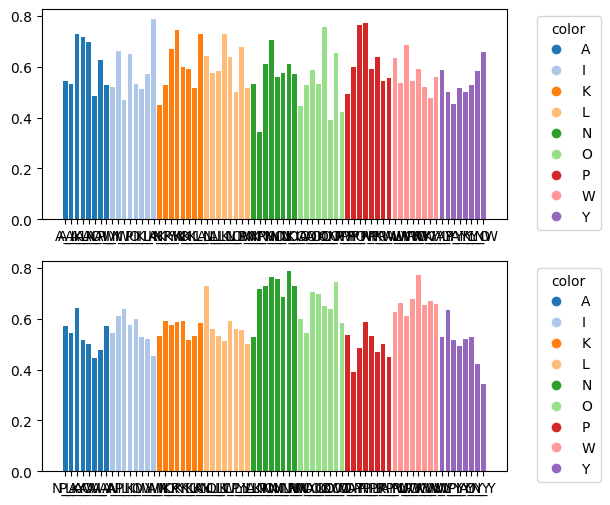

In [11]:
new_df = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean()
new_df = new_df.reset_index()
new_df["StartEnd"] = new_df["StartAt"] + "_" + new_df["EndAt"]

fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(6, 6))

# colors = {'A':'tab:blue', 'I':'tab:orange', 'K':'tab:green', 'L':'tab:red', 'N':'tab:purple', 'O':'tab:brown', 'P':'tab:pink', 'W':'tab:o'}
new_df = new_df.sort_values("StartAt")
color_dict = {k:v for k, v in zip(new_df["StartAt"].unique(), plt.get_cmap('tab20').colors)}

new_df["colors"] = new_df["StartAt"].apply(lambda x: color_dict[x])

ax.bar(new_df["StartEnd"], new_df["accuracy"], color=new_df["colors"])

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

### COPY PASTE
new_df = new_df.sort_values("EndAt")
color_dict = {k:v for k, v in zip(new_df["EndAt"].unique(), plt.get_cmap('tab20').colors)}

new_df["colors"] = new_df["EndAt"].apply(lambda x: color_dict[x])



ax2.bar(new_df["StartEnd"], new_df["accuracy"], color=new_df["colors"])

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax2.legend(title='color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()